In [190]:
# 그림을 저장할 위치
import os
PROJECT_ROOT_DIR = "./fdr_output"
CHAPTER_ID = "stock_check"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
SAMPLES_PATH = os.path.join(PROJECT_ROOT_DIR, "samples", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)
os.makedirs(SAMPLES_PATH, exist_ok=True)

#파일 경로 생성함수
def mkfile(file): 
    file = os.path.join(SAMPLES_PATH,f'{file}.xlsx')
    return file

sample_o = os.path.join(SAMPLES_PATH,'sample.xlsx')
test = os.path.join(SAMPLES_PATH,'test.xlsx')
sample_modi = os.path.join(SAMPLES_PATH,'sample_modi.xlsx')
sample_modi1 = os.path.join(SAMPLES_PATH,'sample_modi1.xlsx')

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("그림 저장:", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 결측치제거 및 scaling
def scale(df):
    from sklearn.preprocessing import MinMaxScaler
    import pandas as pd
    df = df.fillna(method='pad').dropna(axis=0)
    scaler = MinMaxScaler()
    scaler.fit(df)
    output = scaler.transform(df)
    output = pd.DataFrame(output, columns=df.columns, index=df.index.values)
    return output
    
# 시각화
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

mpl.rcParams['axes.unicode_minus'] = False
path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=path, size=50).get_name()
plt.rc('font', family=font_name)

plt.rcParams["axes.grid"] = True
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["axes.formatter.limits"] = -10000, 10000
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)



# 불필요한 경고를 무시합니다 (사이파이 이슈 #5998 참조)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### 선행지수

[선행지표 확인](https://nbviewer.jupyter.org/github/FinanceData/FinanceDataReader/blob/master/tutorial/FinanceDataReader%20Tutorial%20-%20FRED%20%EA%B2%BD%EA%B8%B0%20%EC%84%A0%ED%96%89%20%EC%A7%80%ED%91%9C.ipynb)
+ 주간 실업수당 청구 건수 (ICSA)
+ 소비자심리지수 (UMCSENT)
+ 주택 판매 지수 (HSN1F)
+ 실업률 (UNRATE)
+ M2 통화량(M2)
+ 하이일드 채권 스프레드 (BAMLH0A0HYM2)

In [193]:
df = fdr.DataReader(['NASDAQCOM', 'ICSA', 'UMCSENT','M2','BAMLH0A0HYM2'],'2019', data_source='fred')
df = scale(df)
df.head()

,NASDAQCOM,BAMLH0A0HYM2,UMCSENT,M2,ICSA
2019-01-07,0.000000,0.193591,0.664384,0.0,0.00285
2019-01-08,0.011528,0.169559,0.664384,0.0,0.00285
2019-01-09,0.020947,0.152203,0.664384,0.0,0.00285
2019-01-10,0.025491,0.154873,0.664384,0.0,0.00285
2019-01-11,0.023204,0.156208,0.664384,0.0,0.00285


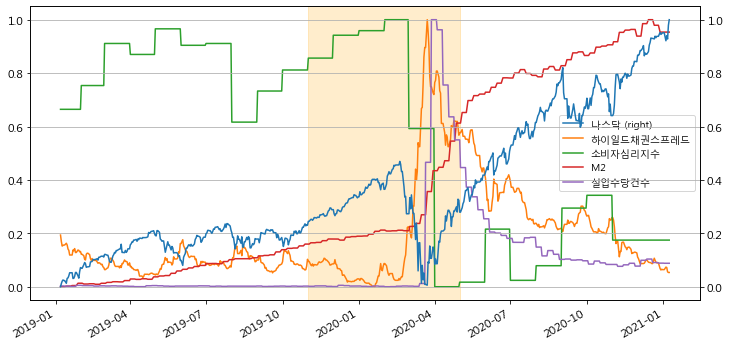

In [120]:
col = ['나스닥','하이일드채권스프레드','소비자심리지수','M2','실업수당건수']
df.columns = col
ax = df.plot(secondary_y='나스닥')
ax = ax.axvspan('2019-11-01','2020-05-01', color='orange', alpha=0.2)

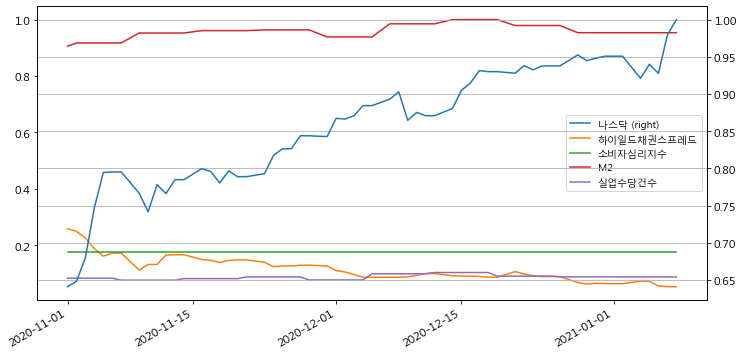

In [121]:
ax = df.tail(60).plot(secondary_y='나스닥')

In [78]:
 df.corr() # 상관관계 확인

,나스닥,하이일드채권스프레드,소비자심리지수,M2,실업수당건수
나스닥,1.000000,0.004472,-0.633193,0.905068,0.079188
하이일드채권스프레드,0.004472,1.000000,-0.625803,0.385420,0.820082
소비자심리지수,-0.633193,-0.625803,1.000000,-0.866010,-0.619213
M2,0.905068,0.385420,-0.866010,1.000000,0.378519
실업수당건수,0.079188,0.820082,-0.619213,0.378519,1.000000


### 주가지수

[지표정보 확인](https://github.com/FinanceData/FinanceDataReader/wiki/Quick-Reference#%EC%A3%BC%EC%9A%94-%EC%A7%80%EC%88%98)

#### 종목리스트 생성

In [103]:
from openpyxl import Workbook
from pandas import ExcelWriter
import pandas as pd

stock_list = mkfile('stock_list') # 파일 경로/이름 생성
stocklist = ['SP500','NASDAQ','KRX'] # 리스트 받아올 항목 정리
wb = Workbook()
all_df = []

all_df = [fdr.StockListing(stock) for stock in stocklist]

writer = pd.ExcelWriter(stock_list, engine='xlsxwriter') 

for idx,sheet in enumerate(all_df):
    sheet.to_excel(writer, sheet_name = stocklist[idx],header=True,index=False)
writer.save()

C:\Dev\Miniconda3\lib\site-packages\FinanceDataReader\wikipedia\listing.py:13: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Symbol'] = df['Symbol'].str.replace('\.', '')
100%|█████████████████████████████████████| 3299/3299 [00:09<00:00, 355.05it/s]


#### 개별종목 주가

<AxesSubplot:xlabel='Date'>

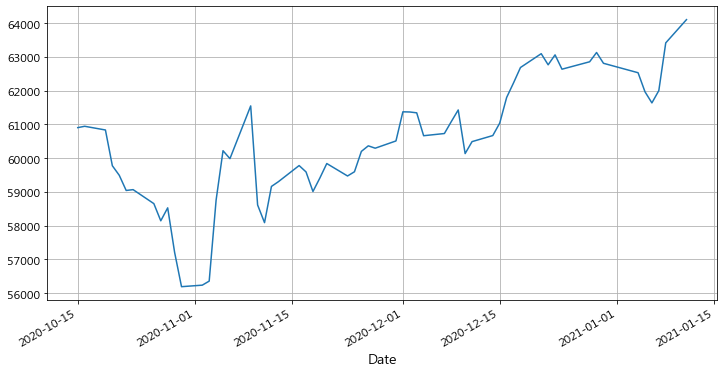

In [181]:
import FinanceDataReader as fdr

df = fdr.DataReader('133690', '2015')
df['Close'].tail(60).plot()

In [230]:
def mp_o(ticker_list, start):
    df= pd.DataFrame()
    for ticker in ticker_list:
        df_s = fdr.DataReader(ticker, start)
        df_s = scale(df_s)
        df[ticker] = df_s['Close']
    return df
def mp(ticker_list, stock_list, start):
    df= pd.DataFrame()
    for idx, ticker in enumerate(ticker_list):
        df_s = fdr.DataReader(ticker, start)
        df_s = scale(df_s)
        df[stock_list[idx]] = df_s['Close']
    return df

In [215]:
ticker_list = ['DJI','IXIC','NG','GC','SI','CL']
df= pd.DataFrame()
for ticker in ticker_list:
    df_s = fdr.DataReader(ticker, '2020')
    df_s = scale(df_s)
    df[ticker] = df_s['Close']
df

,DJI,IXIC,NG,GC,SI,CL
2020-01-02,0.821753,0.351903,0.341880,0.920476,0.124475,0.312097
2020-01-03,0.803048,0.340640,0.346154,0.911256,0.124475,0.308305
2020-01-06,0.808525,0.348635,0.348825,0.883212,0.124625,0.326128
2020-01-07,0.798954,0.348179,0.363248,0.893200,0.129874,0.290482
2020-01-08,0.811861,0.357745,0.352030,0.869381,0.131974,0.355707
...,...,...,...,...,...,...
2021-01-04,0.930107,0.920597,0.587073,0.930465,0.889472,0.926811
2021-01-05,0.943518,0.939601,0.651709,0.932386,0.907019,0.934016
2021-01-06,0.978525,0.927274,0.659188,0.927776,0.908968,0.847933
2021-01-07,0.995455,0.978791,0.666132,0.926623,0.989952,0.830868


In [234]:
l = ['DJI','IXIC','KS11','NG','GC','SI','CL','US10YT=X']
s = ['다우존스','NASDAQ','KOSPI','천연가스선물','금선물','은선물','구리선물','미국채10년물']
df1 = mp(l,s,'2020')

In [1]:
df2 = fdr.DataReader(['NASDAQCOM', 'ICSA', 'UMCSENT','M2','BAMLH0A0HYM2'],'2020', data_source='fred')
col = ['나스닥','하이일드채권스프레드','소비자심리지수','M2','실업수당건수']
df2.columns = col
df2 = scale(df2)
pd.concat([df1,df2], axis=1).corr()

NameError: name 'fdr' is not defined